In [14]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [6]:
DATA_PATH = "/content/drive/MyDrive/Tomato___healthy"

In [15]:


import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import os
from PIL import Image
from torch.utils.data import Dataset, DataLoader
from torchvision.utils import make_grid, save_image

In [16]:
batch_size = 64
image_size = 64
nz = 100          # Noise vector size
ngf = 64          # Generator features
ndf = 64          # Discriminator features
num_epochs = 50
lr = 0.0002
beta1 = 0.5
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [17]:
class TomatoDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.root_dir = root_dir
        self.transform = transform
        self.image_files = [
            f for f in os.listdir(root_dir)
            if f.lower().endswith((".jpg", ".png"))
        ]

    def __len__(self):
        return len(self.image_files)

    def __getitem__(self, idx):
        img_path = os.path.join(self.root_dir, self.image_files[idx])
        image = Image.open(img_path).convert("RGB")

        if self.transform:
            image = self.transform(image)

        return image

In [19]:
transform = transforms.Compose([
    transforms.Resize(image_size),
    transforms.CenterCrop(image_size),
    transforms.ToTensor(),
    transforms.Normalize((0.5,0.5,0.5),(0.5,0.5,0.5))
])

dataset = TomatoDataset(
    root_dir="/content/drive/MyDrive/healthy/tomato",
    transform=transform
)

dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

print("Total images:", len(dataset))

Total images: 221


In [20]:
class Generator(nn.Module):
    def __init__(self):
        super(Generator, self).__init__()
        self.main = nn.Sequential(
            nn.ConvTranspose2d(nz, ngf*8, 4, 1, 0, bias=False),
            nn.BatchNorm2d(ngf*8),
            nn.ReLU(True),

            nn.ConvTranspose2d(ngf*8, ngf*4, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ngf*4),
            nn.ReLU(True),

            nn.ConvTranspose2d(ngf*4, ngf*2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ngf*2),
            nn.ReLU(True),

            nn.ConvTranspose2d(ngf*2, ngf, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ngf),
            nn.ReLU(True),

            nn.ConvTranspose2d(ngf, 3, 4, 2, 1, bias=False),
            nn.Tanh()
        )

    def forward(self, input):
        return self.main(input)

In [21]:
class Discriminator(nn.Module):
    def __init__(self):
        super(Discriminator, self).__init__()
        self.main = nn.Sequential(
            nn.Conv2d(3, ndf, 4, 2, 1, bias=False),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(ndf, ndf*2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ndf*2),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(ndf*2, ndf*4, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ndf*4),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(ndf*4, ndf*8, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ndf*8),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(ndf*8, 1, 4, 1, 0, bias=False),
            nn.Sigmoid()
        )

    def forward(self, input):
        return self.main(input)

In [22]:
netG = Generator().to(device)
netD = Discriminator().to(device)

criterion = nn.BCELoss()

optimizerD = optim.Adam(netD.parameters(), lr=lr, betas=(beta1, 0.999))
optimizerG = optim.Adam(netG.parameters(), lr=lr, betas=(beta1, 0.999))

In [23]:
for epoch in range(num_epochs):
    for i, real_images in enumerate(dataloader):

        real_images = real_images.to(device)
        b_size = real_images.size(0)

        # Real labels
        real_labels = torch.ones(b_size, device=device)
        fake_labels = torch.zeros(b_size, device=device)

        # Train Discriminator
        netD.zero_grad()

        output_real = netD(real_images).view(-1)
        lossD_real = criterion(output_real, real_labels)

        noise = torch.randn(b_size, nz, 1, 1, device=device)
        fake_images = netG(noise)

        output_fake = netD(fake_images.detach()).view(-1)
        lossD_fake = criterion(output_fake, fake_labels)

        lossD = lossD_real + lossD_fake
        lossD.backward()
        optimizerD.step()

        # Train Generator
        netG.zero_grad()
        output = netD(fake_images).view(-1)
        lossG = criterion(output, real_labels)
        lossG.backward()
        optimizerG.step()

    print(f"Epoch [{epoch+1}/{num_epochs}] "
          f"Loss D: {lossD.item():.4f}, "
          f"Loss G: {lossG.item():.4f}")

Epoch [1/50] Loss D: 0.2458, Loss G: 5.2387
Epoch [2/50] Loss D: 0.1613, Loss G: 6.8780
Epoch [3/50] Loss D: 0.1942, Loss G: 9.6158
Epoch [4/50] Loss D: 0.0790, Loss G: 9.2787
Epoch [5/50] Loss D: 0.0252, Loss G: 11.9650
Epoch [6/50] Loss D: 0.1742, Loss G: 15.3641
Epoch [7/50] Loss D: 0.3136, Loss G: 12.3498
Epoch [8/50] Loss D: 2.1913, Loss G: 16.4143
Epoch [9/50] Loss D: 0.0188, Loss G: 12.7435
Epoch [10/50] Loss D: 0.1045, Loss G: 16.3614
Epoch [11/50] Loss D: 0.0114, Loss G: 11.5499
Epoch [12/50] Loss D: 0.0337, Loss G: 9.7286
Epoch [13/50] Loss D: 0.0182, Loss G: 14.1499
Epoch [14/50] Loss D: 0.3308, Loss G: 14.6944
Epoch [15/50] Loss D: 1.9099, Loss G: 14.4512
Epoch [16/50] Loss D: 0.5465, Loss G: 8.2088
Epoch [17/50] Loss D: 0.5570, Loss G: 5.5506
Epoch [18/50] Loss D: 0.0381, Loss G: 5.4363
Epoch [19/50] Loss D: 0.0639, Loss G: 5.2214
Epoch [20/50] Loss D: 1.2489, Loss G: 11.1799
Epoch [21/50] Loss D: 1.1545, Loss G: 10.2769
Epoch [22/50] Loss D: 1.1570, Loss G: 10.0829
Epoch 

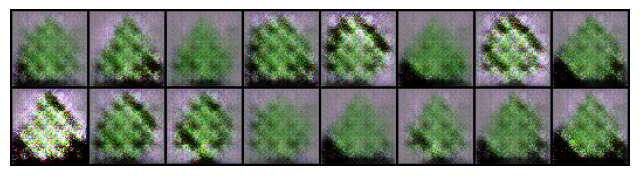

In [24]:
os.makedirs("/content/drive/MyDrive/generated_tomatoes", exist_ok=True)

noise = torch.randn(16, nz, 1, 1, device=device)
fake_images = netG(noise).detach().cpu()

grid = make_grid(fake_images, normalize=True)

plt.figure(figsize=(8,8))
plt.imshow(grid.permute(1,2,0))
plt.axis("off")
plt.show()

# Save individual images
for i in range(16):
    save_image(fake_images[i],
               f"/content/drive/MyDrive/generated_tomatoes/tomato_{i}.png",
               normalize=True)

In [25]:
#STYLE GAN

import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import os
from PIL import Image
from torch.utils.data import Dataset, DataLoader
from torchvision.utils import save_image, make_grid

In [26]:
batch_size = 32
image_size = 64
latent_dim = 128
num_epochs = 50
lr = 0.0002
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [27]:
class TomatoDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.root_dir = root_dir
        self.transform = transform
        self.image_files = [
            f for f in os.listdir(root_dir)
            if f.lower().endswith((".jpg", ".png"))
        ]

    def __len__(self):
        return len(self.image_files)

    def __getitem__(self, idx):
        img_path = os.path.join(self.root_dir, self.image_files[idx])
        image = Image.open(img_path).convert("RGB")
        if self.transform:
            image = self.transform(image)
        return image

In [28]:
transform = transforms.Compose([
    transforms.Resize(image_size),
    transforms.CenterCrop(image_size),
    transforms.ToTensor(),
    transforms.Normalize((0.5,0.5,0.5),(0.5,0.5,0.5))
])

dataset = TomatoDataset(
    root_dir="/content/drive/MyDrive/healthy/tomato",
    transform=transform
)

dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

print("Total images:", len(dataset))

Total images: 221


In [29]:
class MappingNetwork(nn.Module):
    def __init__(self, latent_dim):
        super().__init__()
        self.mapping = nn.Sequential(
            nn.Linear(latent_dim, 256),
            nn.ReLU(),
            nn.Linear(256, 256),
            nn.ReLU(),
            nn.Linear(256, 256)
        )

    def forward(self, z):
        return self.mapping(z)

In [30]:
class AdaIN(nn.Module):
    def __init__(self, channels, style_dim):
        super().__init__()
        self.fc = nn.Linear(style_dim, channels * 2)

    def forward(self, x, style):
        style = self.fc(style)
        gamma, beta = style.chunk(2, dim=1)
        gamma = gamma.unsqueeze(2).unsqueeze(3)
        beta = beta.unsqueeze(2).unsqueeze(3)

        mean = x.mean([2,3], keepdim=True)
        std = x.std([2,3], keepdim=True) + 1e-8
        x = (x - mean) / std
        return gamma * x + beta

In [31]:
class StyleGenerator(nn.Module):
    def __init__(self, latent_dim):
        super().__init__()

        self.mapping = MappingNetwork(latent_dim)

        self.initial = nn.Parameter(torch.randn(1, 256, 4, 4))

        self.conv1 = nn.Conv2d(256, 128, 3, padding=1)
        self.adain1 = AdaIN(128, 256)

        self.conv2 = nn.Conv2d(128, 64, 3, padding=1)
        self.adain2 = AdaIN(64, 256)

        self.to_rgb = nn.Conv2d(64, 3, 1)

        self.upsample = nn.Upsample(scale_factor=2)

    def forward(self, z):
        style = self.mapping(z)

        x = self.initial.repeat(z.size(0),1,1,1)

        x = self.upsample(x)
        x = self.conv1(x)
        x = self.adain1(x, style)
        x = torch.relu(x)

        x = self.upsample(x)
        x = self.conv2(x)
        x = self.adain2(x, style)
        x = torch.relu(x)

        x = self.upsample(x)
        x = self.to_rgb(x)
        return torch.tanh(x)

In [35]:
class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 64, 4, 2, 1),
            nn.LeakyReLU(0.2),

            nn.Conv2d(64, 128, 4, 2, 1),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2),

            nn.Conv2d(128, 256, 4, 2, 1),
            nn.BatchNorm2d(256),
            nn.LeakyReLU(0.2),
        )

        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d((1,1)),  # 🔥 Key Fix
            nn.Flatten(),
            nn.Linear(256, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

In [36]:
netG = StyleGenerator(latent_dim).to(device)
netD = Discriminator().to(device)

criterion = nn.BCELoss()

optimizerD = optim.Adam(netD.parameters(), lr=lr)
optimizerG = optim.Adam(netG.parameters(), lr=lr)

In [37]:
for epoch in range(num_epochs):
    for real_images in dataloader:

        real_images = real_images.to(device)
        b_size = real_images.size(0)

        real_labels = torch.ones(b_size,1).to(device)
        fake_labels = torch.zeros(b_size,1).to(device)

        # Train Discriminator
        optimizerD.zero_grad()
        output_real = netD(real_images)
        lossD_real = criterion(output_real, real_labels)

        z = torch.randn(b_size, latent_dim).to(device)
        fake_images = netG(z)
        output_fake = netD(fake_images.detach())
        lossD_fake = criterion(output_fake, fake_labels)

        lossD = lossD_real + lossD_fake
        lossD.backward()
        optimizerD.step()

        # Train Generator
        optimizerG.zero_grad()
        output = netD(fake_images)
        lossG = criterion(output, real_labels)
        lossG.backward()
        optimizerG.step()

    print(f"Epoch {epoch+1}/{num_epochs} "
          f"Loss D: {lossD.item():.4f} "
          f"Loss G: {lossG.item():.4f}")

Epoch 1/50 Loss D: 1.2879 Loss G: 0.8309
Epoch 2/50 Loss D: 1.2407 Loss G: 0.8308
Epoch 3/50 Loss D: 1.2070 Loss G: 0.8580
Epoch 4/50 Loss D: 1.1628 Loss G: 0.8724
Epoch 5/50 Loss D: 1.1512 Loss G: 0.8894
Epoch 6/50 Loss D: 1.1709 Loss G: 0.8588
Epoch 7/50 Loss D: 1.1469 Loss G: 0.8732
Epoch 8/50 Loss D: 1.1283 Loss G: 0.8743
Epoch 9/50 Loss D: 1.0861 Loss G: 0.9010
Epoch 10/50 Loss D: 1.1241 Loss G: 0.8851
Epoch 11/50 Loss D: 1.0444 Loss G: 0.9811
Epoch 12/50 Loss D: 0.9988 Loss G: 0.9804
Epoch 13/50 Loss D: 1.0392 Loss G: 0.9544
Epoch 14/50 Loss D: 0.9829 Loss G: 0.9747
Epoch 15/50 Loss D: 0.9814 Loss G: 1.0212
Epoch 16/50 Loss D: 0.8959 Loss G: 1.0767
Epoch 17/50 Loss D: 0.9033 Loss G: 1.0591
Epoch 18/50 Loss D: 0.8741 Loss G: 1.0805
Epoch 19/50 Loss D: 0.8396 Loss G: 1.0854
Epoch 20/50 Loss D: 0.8458 Loss G: 1.1207
Epoch 21/50 Loss D: 0.8371 Loss G: 1.1052
Epoch 22/50 Loss D: 0.7748 Loss G: 1.1904
Epoch 23/50 Loss D: 0.7567 Loss G: 1.2005
Epoch 24/50 Loss D: 0.7348 Loss G: 1.2378
E

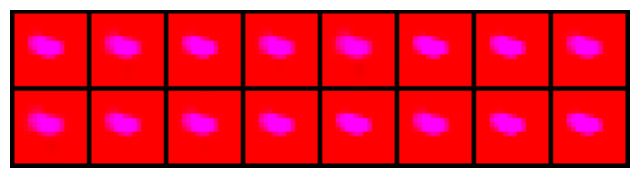

In [39]:
os.makedirs("/content/drive/MyDrive/generated_stylegan_tomatoes", exist_ok=True)

z = torch.randn(16, latent_dim).to(device)
fake_images = netG(z).detach().cpu()

grid = make_grid(fake_images, normalize=True)

plt.figure(figsize=(8,8))
plt.imshow(grid.permute(1,2,0))
plt.axis("off")
plt.show()

for i in range(16):
    save_image(fake_images[i],
               f"/content/drive/MyDrive/generated_stylegan_tomatoes/tomato_{i}.png",
               normalize=True)